<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/Flower_Dataset_Using_Data_Augmentation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


In [2]:
(ds_train, ds_val), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features['label'].num_classes
class_names = ds_info.features['label'].names

print("Class Names:",class_names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.XEG0ZU_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Class Names: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

#Processing the data

In [4]:
ds_train = (
    ds_train
    .map(preprocess)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_val = (
    ds_val
    .map(preprocess)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

#Visualizing the data

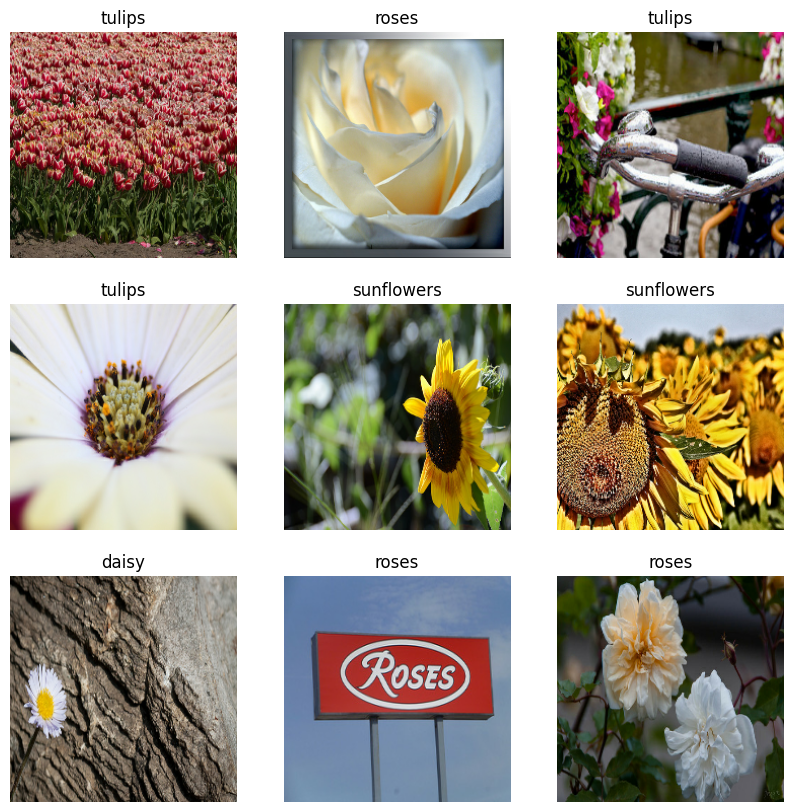

In [5]:
plt.figure(figsize=(10,10))

for images,labels in ds_train.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis('off')


plt.show()

In [6]:
from tensorflow import keras

data_augmentation=keras.Sequential(
    [
        keras.layers.RandomFlip('horizontal'),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.1),
        keras.layers.RandomContrast(0.1)
    ]
)


In [7]:
from tensorflow.keras import models,layers
cnn=models.Sequential(
    [
        data_augmentation,

        layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(IMG_SIZE,IMG_SIZE,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64,(3,3),activation='relu',padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu',padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dense(NUM_CLASSES,activation='softmax')



    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(ds_train,
    validation_data=ds_val,
    epochs=50)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.7548 - loss: 0.6419 - val_accuracy: 0.7466 - val_loss: 0.6706
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7759 - loss: 0.5890 - val_accuracy: 0.7398 - val_loss: 0.6993
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.7824 - loss: 0.5691 - val_accuracy: 0.7575 - val_loss: 0.6544
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8011 - loss: 0.5127 - val_accuracy: 0.7684 - val_loss: 0.6263
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8076 - loss: 0.5149 - val_accuracy: 0.7561 - val_loss: 0.6687
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8157 - loss: 0.4827 - val_accuracy: 0.7507 - val_loss: 0.7290
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8290 - loss: 0.4586 - val_accuracy: 0.7575 - val_loss: 0.6886
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8372 - loss: 0.4380 - val_accuracy: 0.7643 - v

In [10]:
cnn.evaluate(ds_val)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7302 - loss: 0.6752


[0.6751841902732849, 0.7302452325820923]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


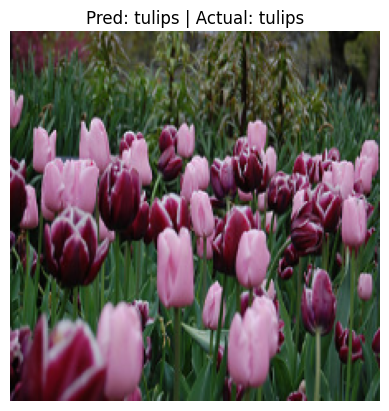

In [14]:
for images, labels in ds_val.take(1):
    predictions = cnn.predict(images)

    pred_label = tf.argmax(predictions[1])

    plt.imshow(images[1])
    plt.title(f"Pred: {class_names[pred_label]} | Actual: {class_names[labels[1]]}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


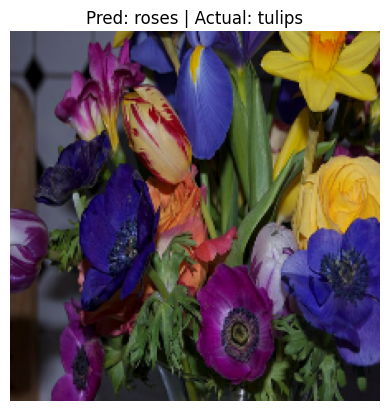

In [15]:
for images, labels in ds_val.take(1):
    predictions = cnn.predict(images)

    pred_label = tf.argmax(predictions[2])

    plt.imshow(images[2])
    plt.title(f"Pred: {class_names[pred_label]} | Actual: {class_names[labels[2]]}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


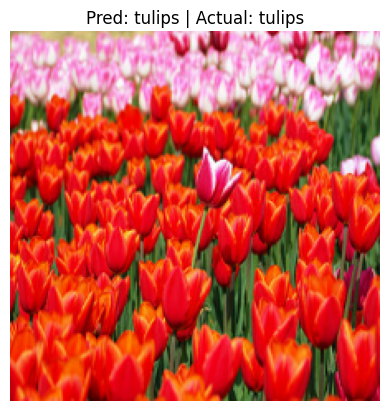

In [16]:
for images, labels in ds_val.take(1):
    predictions = cnn.predict(images)

    pred_label = tf.argmax(predictions[3])

    plt.imshow(images[3])
    plt.title(f"Pred: {class_names[pred_label]} | Actual: {class_names[labels[3]]}")
    plt.axis('off')
    plt.show()